### Initialization

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
init = "spectral"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
DATA_DIR = "~/Desktop/Projects/media-prediction/"
RANDOM_SEED = 26

### Import data

In [20]:
# Loading constructed dataset
df = pd.read_csv(os.path.join(DATA_DIR, "data", "UMAP_input.csv"), low_memory=False)

df.head()

,taxon_id,media_id,1.1.1.1,1.1.1.100,1.1.1.101,1.1.1.102,1.1.1.103,1.1.1.105,1.1.1.107,1.1.1.108,...,7.6.2.12,7.6.2.13,7.6.2.14,7.6.2.15,7.6.2.16,7.6.2.2,7.6.2.5,7.6.2.7,7.6.2.8,7.6.2.9
0,100.0,J346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100.0,J386,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100225.0,J233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1002526.0,J22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1004166.0,1a,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
# Upload test case (.csv with columns ["filename", "ec"] from 01-Data.ipynb output)
test_df = pd.read_csv(os.path.join(DATA_DIR, "data", "test.csv"))

# Select a single test sample
bin = test_df[test_df["filename"].str.contains("Bin.003.fastaCG_F", na=False)]

# Format for UMAP
bin = bin[["filename", "ec"]].value_counts().reset_index()
test = bin.pivot(index=["filename"], columns="ec", values="count").fillna(0.0)

test.head()

ec,1.11.1.15,1.15.1.1,1.2.7.3,1.3.1.98,2.1.1.170,2.1.1.177,2.1.1.192,2.1.1.193,2.1.1.198,2.1.1.199,...,6.1.1.2,6.1.1.20,6.1.1.3,6.1.1.4,6.1.1.6,6.1.1.7,6.1.1.9,6.3.5.6,7.1.2.2,7.4.2.8
filename,,,,,,,,,,,,,,,,,,,,,
KBase_derived_Bin.003.fastaCG_F_extracted_bins.AssemblySet_DRAM.gff,1,1,1,1,1,1,1,1,1,1,...,1,2,1,1,1,1,1,2,2,1


### UMAP
UMAP is used to reduce dimensionality and map the test organism to the metabolic space of the training dataset. Use this in combination with the K-Nearest Neighbors to visualize how closely your organism fits with the training dataset to inform media predictions.

#### UMAP model

In [23]:
# UMAP dimensionality reduction
import umap

model = umap.UMAP(      
        metric="jaccard",
        n_epochs=500,
        random_state=RANDOM_SEED,
        n_jobs=1,
        n_components=20, 
        n_neighbors=40, 
        min_dist=0.1 
        )

# Fit/transform data using UMAP
X_train = df.drop(["taxon_id", "media_id"], axis=1)
X_train_transformed = model.fit_transform(X_train)

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\pynndescent\pynndescent_.py:939: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\umap\umap_.py:127: UserWarning: A few of your vertices were disconnected from the manifold.  This shouldn't cause problems.
Disconnection_distance = 1 has removed 3699 edges.
It has only fully disconnected 60 vertices.
Use umap.utils.disconnected_vertices() to identify them.
  warn(


In [24]:
# Check disconnected vertices

nan_rows = np.isnan(X_train_transformed).any(axis=1)
n_samples = X_train_transformed.shape[0]
n_nan_rows = np.isnan(X_train_transformed).any(axis=1).sum()
percent_nan_rows = 100 * n_nan_rows / n_samples

print(percent_nan_rows, "percent of embedded samples are nan (disconnected vertices / total samples).")

0.7088846880907372 percent of embedded samples are nan (disconnected vertices / total samples).


#### Clustering

In [37]:
# Cluster embedding
from sklearn.cluster import KMeans

X_train_clean = X_train_transformed[~nan_rows]
clusterer = KMeans(n_clusters=14, n_init=50, random_state=RANDOM_SEED)
cluster_labels = clusterer.fit_predict(X_train_clean)

# Clustering performance
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_train_clean, cluster_labels)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")

14 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.7286314964294434


#### Transform test case

In [42]:
# Resize test case to include all of the same EC numbers as the training dataset
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

train = df.copy()
train = train.drop(["taxon_id", "media_id"], axis=1)

for col in train.columns:
    if col not in test.columns:
        test[col] = 0

test = test[train.columns]

# Transform the test case with UMAP
test_embedding = model.transform(test)

#### Visualization

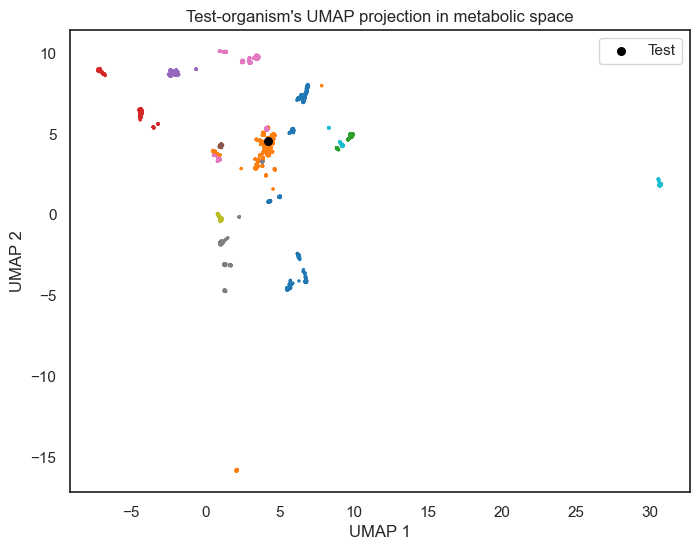

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Reference organisms from constructed dataset
plt.scatter(X_train_clean[:,0], X_train_clean[:,1], c=cluster_labels, cmap="tab10", s=2) 
    # Components 13 and 18 (and 19) determined highest importance via XGBoost/Shap
    # Components 1 and 18 give a nice distribution for visualization

# Test sample
plt.scatter(test_embedding[0, 0], test_embedding[0, 1], c="black", s=30, label="Test")

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Test-organism's UMAP projection in metabolic space")
plt.legend()
plt.show()

### Nearest neighbors

In [44]:
# Function for finding nearest neighbors via the jaccard metric (uses original dataset)
from sklearn.neighbors import NearestNeighbors

def get_nearest_neighbors(X_train, new_sample, k=5, metric='jaccard'):
    nn = NearestNeighbors(n_neighbors=k, metric="jaccard")
    nn.fit(train)
    distances, indices = nn.kneighbors(test)
    
    return distances[0], indices[0]

In [45]:
# Return nearest neighbors
distances, indices = get_nearest_neighbors(train, test, k=5)
nearest_info = df.iloc[indices][['taxon_id', 'media_id']].copy()

print(nearest_info)

       taxon_id media_id
6419    47834.0    1076b
362   1136073.0    1076b
6420    47835.0    1076b
5422   358687.0     J346
5357   351343.0     J346


c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


### Feature importance

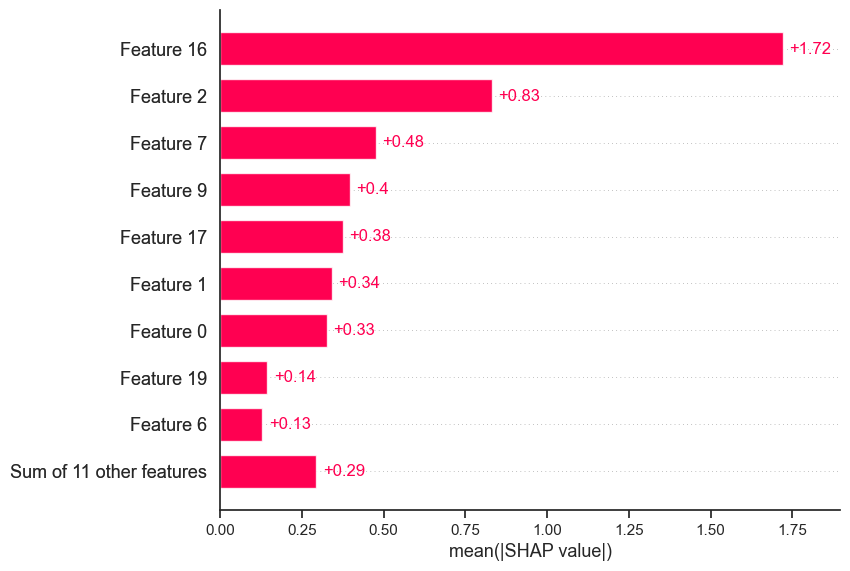

In [46]:
# UMAP Features
import xgboost
import shap

XG_train = X_train_clean
yG_train = cluster_labels

model = xgboost.XGBRegressor().fit(XG_train, yG_train)
explainer = shap.Explainer(model)
shap_values = explainer(XG_train)

shap.plots.initjs()
shap.plots.bar(shap_values)

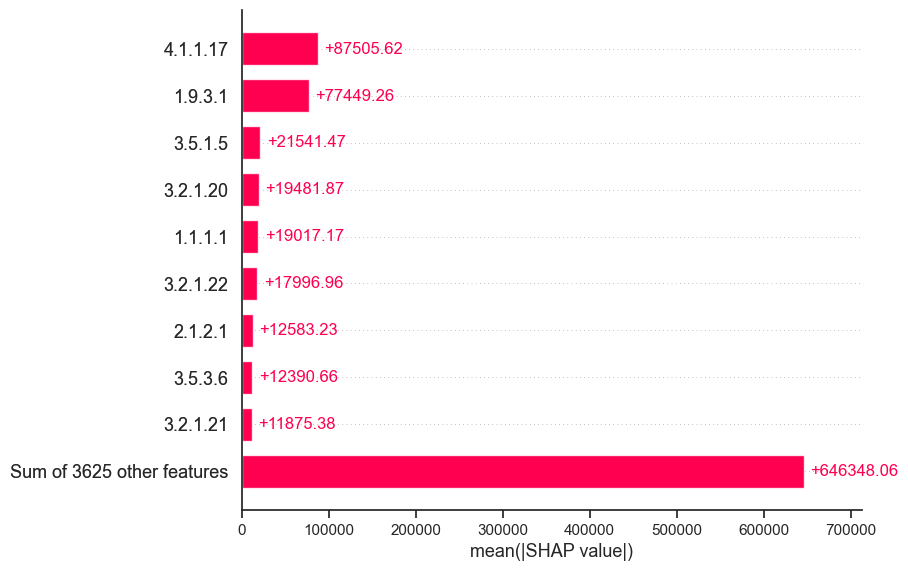

In [51]:
# Initial features (EC numbers)
XG_train = df.drop(["taxon_id", "media_id"], axis=1)
yG_train = df["taxon_id"]

model = xgboost.XGBRegressor().fit(XG_train, yG_train)
explainer = shap.Explainer(model)
shap_values = explainer(XG_train)

shap.plots.initjs()
shap.plots.bar(shap_values, max_display=10)

In [ ]:
STOP

### Trace elements

In [ ]:
df = pd.read_csv(os.path.join(DATA_DIR, "data", "TEST1.csv"))
media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False) #"mediadive-complete-explo.csv"

df = df.rename(columns={"neighbor_media_id": "media_id"})
boi = df["taxon_id"].str.contains("Bin.003.fastaCG_F")
data = df[boi]

prediction = pd.merge(left=data, right=media_df, on="media_id", how="left")

print(len(prediction))
prediction.head()

1


,Test Cluster,taxon_id,KNN Classify,RF Classify,media_id,neighbor_taxon_id,Media Cluster,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml
0,67,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,67,67,J363,2499157.0,NaN,[4084],['Main sol. J363'],"['Salt Solution I', 'Salt Solution II', 'Trypt...","[1143, 1144, 124, 16, 5, 214, 171, 199, 1852, ...","[None, None, 9.96016, 4.98008, 0.249004, 0.249...",[[{'step': 'Adjust pH to 6.7. Prepare medium a...,[],[],[]


Let's map some cofactor concentrations:

In [ ]:
# Load ec and cofactor info

trco = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "cofactors-taxa.csv"), low_memory=False)
trco = trco[["Query EC", "CofactorExtracted", "Fe-S cluster", "CofactorFinal"]]
trco = trco.rename(columns={"Query EC": "ec"})

trta = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "ml_input.csv"), low_memory=False)

cfdf = pd.merge(left=trta, right=trco, on="ec", how="left")

cfdf.head()

,media_id,species,taxon_id,source,ec,CofactorExtracted,Fe-S cluster,CofactorFinal
0,1a,Comamonas testosteroni,1886637.0,uniprot,2.6.1.1,NaN,NaN,NaN
1,1a,Comamonas testosteroni,1886637.0,uniprot,4.1.1.12,NaN,NaN,NaN
2,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.74,Fe(2+),False,Fe
3,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.76,Fe(2+),False,Fe
4,1a,Comamonas testosteroni,1886637.0,uniprot,1.14.13.23,NaN,NaN,NaN


In [ ]:
# Focus on metals / trace elements:
metals = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "metals-list.csv")) #TODO: metals list as a given
meli = metals["Metals"].to_list()
filter = cfdf["CofactorFinal"].isin(meli)
meco = cfdf[filter]

meco.head()

,media_id,species,taxon_id,source,ec,CofactorExtracted,Fe-S cluster,CofactorFinal
2,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.74,Fe(2+),False,Fe
3,1a,Comamonas testosteroni,1886637.0,uniprot,1.13.11.76,Fe(2+),False,Fe
7,1a,Comamonas testosteroni,1886637.0,uniprot,1.1.9.1,Ca(2+),False,Ca
8,1a,Comamonas testosteroni,1886637.0,uniprot,1.1.9.1,heme c,False,Fe
15,1a,Comamonas testosteroni,1886637.0,uniprot,1.14.12.15,Fe cation,False,Fe


Now: need a list of each trace element solution utilizing these ~90+ cofactors, and then 1) map the distributions of these concentrations (linear regression, just plot means, distributions, etc.), align these values with the "CofactorFinal", and attempt for a given test case to be able to suggest concentrations based on the EC numbers present (similar to Method 1, but needs refinement)

In [ ]:
comp = meco[["media_id", "taxon_id", "source", "ec", "CofactorFinal"]]
comp = comp.dropna()

# Filters
bins = comp["source"].str.contains("KBase") # Separate MAGs from training database
boi = comp["taxon_id"].str.contains("Bin.003.fastaCG_F") # Isolate a single test MAG

co = comp[~bins]
ct = comp[bins]
test = comp[boi]

#Create, merge, format counts 
coct = co["CofactorFinal"].value_counts().reset_index()
sum1 = coct["count"].sum(axis=0)
coct['ratio1'] = coct['count'].div(sum1)
coct = coct.rename(columns={"count": "count1"})

ctct = ct["CofactorFinal"].value_counts().reset_index()
sum2 = ctct["count"].sum(axis=0)
ctct['ratio2'] = ctct['count'].div(sum2)
ctct = ctct.rename(columns={"count": "count2"})

tect = test["CofactorFinal"].value_counts().reset_index()
sum3 = tect["count"].sum(axis=0)
tect['ratio3'] = tect['count'].div(sum3)
tect = tect.rename(columns={"count": "count3"})

cf_df = pd.merge(left=coct, right=ctct, on="CofactorFinal", how="left")
cf_df = pd.merge(left=cf_df, right=tect, on="CofactorFinal", how="left")
cf_df = cf_df.fillna(0)

x = cf_df["count1"].sum(axis=0)
y = cf_df["count2"].sum(axis=0)
z = cf_df["count3"].sum(axis=0)
print(x, "annotated bin cofactors", y, "annotated database cofactors")


# Relabel cofactors to group organic
relabeled_cofactors = cf_df.copy()
dictionary = {
    "a monovalent": "UM",
    "metal": "UM"
}

for key in dictionary.keys():
    relabeled_cofactors["CofactorFinal"] = relabeled_cofactors["CofactorFinal"].str.replace(key, dictionary[key])

relabeled_cofactors = relabeled_cofactors.groupby(['CofactorFinal'])[['count1', 'ratio1', 'count2', 'ratio2', 'count3', 'ratio3']].sum().reset_index()
relabeled_cofactors = relabeled_cofactors.sort_values(['count1'], ascending=[False])


# Format for visualization
df1 = relabeled_cofactors[["CofactorFinal", "count1", "ratio1"]]
df2 = relabeled_cofactors[["CofactorFinal", "count2", "ratio2"]]
df3 = relabeled_cofactors[["CofactorFinal", "count3", "ratio3"]]

df1 = df1.rename(columns={"count1": "ct", "ratio1": "ra"})
df2 = df2.rename(columns={"count2": "ct", "ratio2": "ra"})
df3 = df3.rename(columns={"count3": "ct", "ratio3": "ra"})

df1["Set"] = "Training"
df2["Set"] = "Test"
df3["Set"] = "Bin 003 CG_F"

frames = df1, df2, df3
df = pd.concat(frames)
df.head()

1683059 annotated bin cofactors 95814.0 annotated database cofactors


,CofactorFinal,ct,ra,Set
7,Mg,433561.0,0.257603,Training
16,Zn,295693.0,0.175688,Training
4,Fe,234241.0,0.139176,Training
8,Mn,174574.0,0.103724,Training
0,Ca,133125.0,0.079097,Training


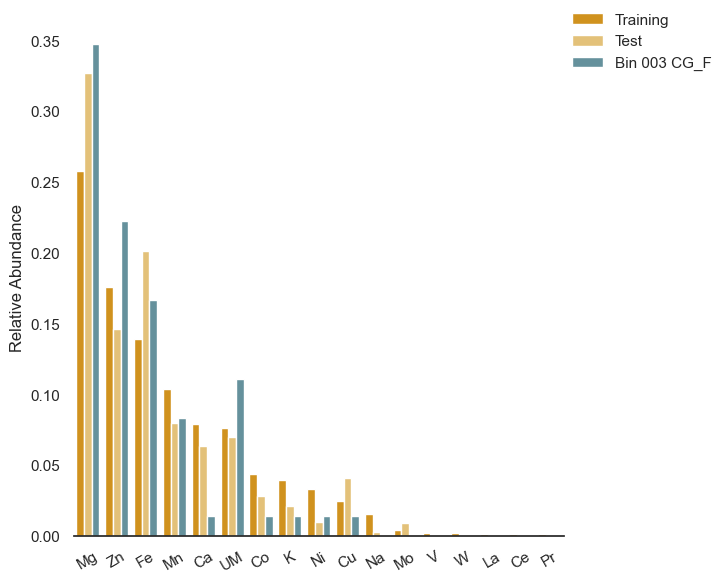

In [ ]:
import seaborn as sns
sns.set_theme(style="white")

colors = ["#ee9b00", "#f5c767", "#5c96a5"]

# Draw a nested barplot by species and sex
g = sns.catplot(
    data=df, kind="bar",
    x="CofactorFinal", y="ra", hue="Set", 
    palette=colors, alpha=1, height=6
)

g.despine(left=True)
g.set_axis_labels("", "Relative Abundance")
g.tick_params(axis='x', rotation=30)
g.legend.set_loc("upper right")
g.legend.set_title("")